<a href="https://colab.research.google.com/github/SammyGbabs/Unsupervised-Discovery-of-Child-Welfare-Archetypes-in-the-African-Union/blob/main/ISW2026_Child_Welfare_Archetypes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multidimensional Child Welfare Profiles in Africa
## A Pattern Recognition Approach to Country Archetypes Beyond Geographic Groupings

**ISW 2026 submission — reproducibility notebook**

This notebook reproduces every experiment and figure in the paper:
1. Loading and cleaning the *Africa's Children 2026 Statistical Compendium* (UNICEF)
2. Imputation benchmark (mean, median, k-NN, MICE, matrix factorization)
3. PCA + clustering with three algorithms
4. Bootstrap stability
5. Comparison against Regional Economic Communities (RECs)
6. Figure generation

## How to use
1. Upload `AfCSC-2026.xlsx` to the Colab file panel (or mount Drive and adjust the path)
2. Run cells top-to-bottom
3. Outputs (CSVs, PDF figures) are written to the working directory and offered as downloads at the end

Total runtime: ~2-3 minutes.

## 0. Setup

In [1]:
# Standard libraries — all preinstalled on Colab
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from openpyxl import load_workbook

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)
from scipy.cluster.hierarchy import linkage

plt.rcParams.update({'font.size': 9, 'font.family': 'serif'})

# Update this path if the file lives elsewhere
DATA_PATH = '/content/AfCSC-2026.xlsx'

# Random seed for reproducibility
SEED = 42
rng = np.random.RandomState(SEED)

## 1. Data Loading & Cleaning

The compendium uses multi-row headers (rows 3-5) per sheet. We parse each of the 21 sheets, rebuild column names, drop regional aggregates and definition rows, and assemble a single country × indicator matrix.

In [2]:
# Canonical AU member states present in the compendium (52 of 55).
# Three are missing from the 2026 release: Central African Republic, South Africa, Western Sahara.
COUNTRIES = [
    'Algeria','Angola','Benin','Botswana','Burkina Faso','Burundi','Cabo Verde',
    'Cameroon','Chad','Comoros','Congo',"Côte d'Ivoire",'Democratic Republic of the Congo',
    'Djibouti','Egypt','Equatorial Guinea','Eritrea','Eswatini','Ethiopia','Gabon','Gambia',
    'Ghana','Guinea','Guinea-Bissau','Kenya','Lesotho','Liberia','Libya','Madagascar','Malawi',
    'Mali','Mauritania','Mauritius','Morocco','Mozambique','Namibia','Niger','Nigeria','Rwanda',
    'Sao Tome and Principe','Senegal','Seychelles','Sierra Leone','Somalia','South Sudan','Sudan',
    'Togo','Tunisia','Uganda','United Republic of Tanzania','Zambia','Zimbabwe',
]

def extract_sheet(path, sheet_name):
    """Read a single sheet, build (country, indicator) tidy frame."""
    df = pd.read_excel(path, sheet_name=sheet_name, header=None)
    cols = ['country']
    for c in range(2, df.shape[1]):
        parts = []
        for r in (3, 4, 5):
            v = df.iloc[r, c] if r < len(df) else None
            if pd.notna(v) and str(v).strip():
                parts.append(str(v).strip().replace('\n', ' '))
        cols.append(f"{sheet_name[:18]}::c{c}::{' | '.join(parts)}" if parts else f"{sheet_name[:18]}::c{c}")
    rows = []
    for r in range(7, df.shape[0]):
        country = df.iloc[r, 1]
        if not isinstance(country, str) or country.strip() not in COUNTRIES:
            continue
        row = [country.strip()]
        for c in range(2, df.shape[1]):
            v = df.iloc[r, c]
            try:
                v = float(v) if pd.notna(v) and v not in ['-', '–', '..'] else np.nan
            except (ValueError, TypeError):
                v = np.nan
            row.append(v)
        rows.append(row)
    return pd.DataFrame(rows, columns=cols)

wb = load_workbook(DATA_PATH, read_only=True)
sheets = [extract_sheet(DATA_PATH, s).drop_duplicates('country').set_index('country')
          for s in wb.sheetnames]
X_full = pd.concat(sheets, axis=1)
X_full = X_full.dropna(axis=1, how='all')  # drop indicators with no data anywhere
print(f'Full matrix: {X_full.shape[0]} countries × {X_full.shape[1]} indicators')
print(f'Overall missingness: {X_full.isna().mean().mean():.1%}')

Full matrix: 52 countries × 325 indicators
Overall missingness: 25.6%


In [3]:
# Restrict to indicators with ≤50% missingness for the experiment matrix
ind_miss = X_full.isna().mean(axis=0)
X = X_full[ind_miss[ind_miss <= 0.50].index]
print(f'Working matrix: {X.shape}, missingness: {X.isna().mean().mean():.1%}')

# REC labels (single primary affiliation per country)
REC = {
    'Algeria':'AMU','Libya':'AMU','Mauritania':'AMU','Morocco':'AMU','Tunisia':'AMU',
    'Burundi':'EAC','Kenya':'EAC','Rwanda':'EAC','South Sudan':'EAC',
    'Uganda':'EAC','United Republic of Tanzania':'EAC',
    'Comoros':'COMESA','Djibouti':'COMESA','Egypt':'COMESA','Eritrea':'COMESA',
    'Eswatini':'COMESA','Ethiopia':'COMESA','Madagascar':'COMESA','Malawi':'COMESA',
    'Mauritius':'COMESA','Seychelles':'COMESA','Somalia':'COMESA','Sudan':'COMESA',
    'Zambia':'COMESA','Zimbabwe':'COMESA',
    'Angola':'SADC','Botswana':'SADC','Lesotho':'SADC','Mozambique':'SADC','Namibia':'SADC',
    'Benin':'ECOWAS','Burkina Faso':'ECOWAS','Cabo Verde':'ECOWAS',"Côte d'Ivoire":'ECOWAS',
    'Gambia':'ECOWAS','Ghana':'ECOWAS','Guinea':'ECOWAS','Guinea-Bissau':'ECOWAS',
    'Liberia':'ECOWAS','Mali':'ECOWAS','Niger':'ECOWAS','Nigeria':'ECOWAS','Senegal':'ECOWAS',
    'Sierra Leone':'ECOWAS','Togo':'ECOWAS',
    'Cameroon':'ECCAS','Chad':'ECCAS','Congo':'ECCAS','Democratic Republic of the Congo':'ECCAS',
    'Equatorial Guinea':'ECCAS','Gabon':'ECCAS','Sao Tome and Principe':'ECCAS',
}
rec_series = pd.Series([REC[c] for c in X.index], index=X.index, name='REC')
print('\nREC distribution:')
print(rec_series.value_counts())

Working matrix: (52, 257), missingness: 14.4%

REC distribution:
REC
ECOWAS    15
COMESA    14
ECCAS      7
EAC        6
SADC       5
AMU        5
Name: count, dtype: int64


## 2. Imputation Benchmark

Hide a random 15% of known cells, run six imputers, measure standardized RMSE on held-out values. Report mean over 5 random splits.

In [4]:
def matrix_factorization_impute(X_arr, k=5, n_iter=200, lr=0.01, reg=0.05, seed=SEED):
    """Low-rank matrix factorization on observed entries with Frobenius regularization."""
    rng_local = np.random.RandomState(seed)
    sc = StandardScaler()
    X_init = SimpleImputer(strategy='mean').fit_transform(X_arr)
    sc.fit(X_init)
    X_s = (X_arr - sc.mean_) / sc.scale_
    mask = ~np.isnan(X_s)
    X_s_filled = np.where(mask, X_s, 0)
    n, m = X_arr.shape
    U = rng_local.randn(n, k) * 0.1
    V = rng_local.randn(m, k) * 0.1
    for _ in range(n_iter):
        pred = U @ V.T
        err = np.where(mask, X_s_filled - pred, 0)
        U += lr * (err @ V - reg * U)
        V += lr * (err.T @ U - reg * V)
    pred = U @ V.T
    full_s = np.where(mask, X_s, pred)
    return full_s * sc.scale_ + sc.mean_

X_arr = X.values.astype(float)
known_mask = ~np.isnan(X_arr)
n_trials = 5

methods = {
    'Column mean':           lambda x: SimpleImputer(strategy='mean').fit_transform(x),
    'Column median':         lambda x: SimpleImputer(strategy='median').fit_transform(x),
    'k-NN (k=5)':            lambda x: KNNImputer(n_neighbors=5).fit_transform(x),
    'k-NN (k=10)':           lambda x: KNNImputer(n_neighbors=10).fit_transform(x),
    'Iterative (MICE)':      lambda x: IterativeImputer(max_iter=10, random_state=SEED).fit_transform(x),
    'Matrix factorization':  matrix_factorization_impute,
}

scores = {m: [] for m in methods}
for trial in range(n_trials):
    rng_t = np.random.RandomState(100 + trial)
    known_idx = np.argwhere(known_mask)
    n_hide = int(0.15 * len(known_idx))
    hide_idx = known_idx[rng_t.choice(len(known_idx), n_hide, replace=False)]
    X_test = X_arr.copy()
    true_vals = np.array([X_test[i, j] for i, j in hide_idx])
    for i, j in hide_idx:
        X_test[i, j] = np.nan
    col_std = np.nanstd(X_test, axis=0)
    col_std[col_std == 0] = 1
    for name, fn in methods.items():
        try:
            X_imp = fn(X_test)
            preds = np.array([X_imp[i, j] for i, j in hide_idx])
            errs = (preds - true_vals) / np.array([col_std[j] for _, j in hide_idx])
            scores[name].append(np.sqrt(np.mean(errs ** 2)))
        except Exception as e:
            scores[name].append(np.nan)
            print(f'  {name} failed on trial {trial}: {e}')

imp_results = pd.DataFrame({
    'Method':    list(scores.keys()),
    'Mean_RMSE': [np.nanmean(v) for v in scores.values()],
    'Std':       [np.nanstd(v)  for v in scores.values()],
})
print(imp_results.to_string(index=False))
imp_results.to_csv('imputation_results.csv', index=False)

              Method  Mean_RMSE      Std
         Column mean   1.100754 0.026480
       Column median   1.141635 0.021899
          k-NN (k=5)   1.183108 0.034219
         k-NN (k=10)   1.131910 0.031621
    Iterative (MICE)   4.552683 0.241360
Matrix factorization   0.913171 0.018306


## 3. Apply Best Imputer & Cluster

Use matrix factorization (best imputer), standardize, run PCA, cluster with three algorithms, evaluate stability and REC agreement.

In [5]:
X_imp = pd.DataFrame(matrix_factorization_impute(X_arr), index=X.index, columns=X.columns)
X_std = StandardScaler().fit_transform(X_imp.values)

pca = PCA(n_components=10, random_state=SEED)
X_pca = pca.fit_transform(X_std)
print(f'PCA-10 cumulative explained variance: {pca.explained_variance_ratio_.sum():.3f}')

# Validity by k
print('\nCluster validity by k:')
print(f"{'k':<4} {'Silhouette':<12} {'Calinski-H':<12}")
for k in range(2, 9):
    lab = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit_predict(X_pca)
    print(f'{k:<4} {silhouette_score(X_pca, lab):<12.4f} {calinski_harabasz_score(X_pca, lab):<12.2f}')

K = 4
km_labels  = KMeans(n_clusters=K, n_init=50, random_state=SEED).fit_predict(X_pca)
agg_labels = AgglomerativeClustering(n_clusters=K, linkage='ward').fit_predict(X_pca)
gmm_labels = GaussianMixture(n_components=K, n_init=10, random_state=SEED).fit_predict(X_pca)

print('\nAlgorithm agreement (ARI):')
print(f'  k-means vs hierarchical: {adjusted_rand_score(km_labels, agg_labels):.3f}')
print(f'  k-means vs GMM:          {adjusted_rand_score(km_labels, gmm_labels):.3f}')
print(f'  hierarchical vs GMM:     {adjusted_rand_score(agg_labels, gmm_labels):.3f}')

rec_codes = pd.Categorical(rec_series.values).codes
print('\nClusters vs REC groupings:')
for name, lab in [('k-means', km_labels), ('hierarchical', agg_labels), ('GMM', gmm_labels)]:
    print(f'  {name:<14} ARI={adjusted_rand_score(rec_codes, lab):.3f}  '
          f'NMI={normalized_mutual_info_score(rec_codes, lab):.3f}')

PCA-10 cumulative explained variance: 0.734

Cluster validity by k:
k    Silhouette   Calinski-H  
2    0.2523       21.38       
3    0.2488       17.57       
4    0.2141       16.17       
5    0.2001       14.60       
6    0.2086       14.14       
7    0.2223       13.33       
8    0.2048       12.93       

Algorithm agreement (ARI):
  k-means vs hierarchical: 0.683
  k-means vs GMM:          0.632
  hierarchical vs GMM:     0.424

Clusters vs REC groupings:
  k-means        ARI=0.104  NMI=0.227
  hierarchical   ARI=0.124  NMI=0.246
  GMM            ARI=0.126  NMI=0.267


In [6]:
# Bootstrap stability
n = X_pca.shape[0]
B = 50
co = np.zeros((n, n)); cnt = np.zeros((n, n))
for b in range(B):
    idx = np.random.RandomState(b).choice(n, n, replace=True)
    Xb = X_pca[idx]
    lab = KMeans(n_clusters=K, n_init=10, random_state=b).fit_predict(Xb)
    for ii, io in enumerate(idx):
        for jj, jo in enumerate(idx):
            cnt[io, jo] += 1
            if lab[ii] == lab[jj]:
                co[io, jo] += 1
rate = np.divide(co, cnt, where=cnt > 0)
within  = [rate[i, j] for i in range(n) for j in range(i+1, n) if km_labels[i] == km_labels[j] and cnt[i, j] > 0]
between = [rate[i, j] for i in range(n) for j in range(i+1, n) if km_labels[i] != km_labels[j] and cnt[i, j] > 0]
print(f'Bootstrap within-cluster co-assignment: {np.mean(within):.3f}')
print(f'Bootstrap between-cluster co-assignment: {np.mean(between):.3f}')
print(f'Stability gap: {np.mean(within) - np.mean(between):.3f}')

# Save assignments
out = pd.DataFrame({
    'country':      X_imp.index,
    'REC':          rec_series.values,
    'cluster_km':   km_labels,
    'cluster_agg':  agg_labels,
    'cluster_gmm':  gmm_labels,
    'PC1':          X_pca[:, 0],
    'PC2':          X_pca[:, 1],
})
out.to_csv('cluster_assignments.csv', index=False)
X_imp.to_csv('imputed_matrix.csv')
print('\nSaved cluster_assignments.csv and imputed_matrix.csv')

Bootstrap within-cluster co-assignment: 0.681
Bootstrap between-cluster co-assignment: 0.135
Stability gap: 0.546

Saved cluster_assignments.csv and imputed_matrix.csv


In [7]:
# Cluster membership and contingency
names = {0: 'Mid-tier', 1: 'Middle', 2: 'High-burden', 3: 'High-perf.'}
for c in [3, 0, 1, 2]:
    members = sorted(out[out['cluster_km'] == c]['country'].tolist())
    print(f'\nCluster {c} ({names[c]}, n={len(members)}):\n  ' + ', '.join(members))

ct = pd.crosstab(out['cluster_km'].map(names), out['REC'])
ct = ct[['AMU', 'COMESA', 'EAC', 'ECCAS', 'ECOWAS', 'SADC']]
print('\nCluster-REC contingency:')
print(ct)


Cluster 3 (High-perf., n=8):
  Algeria, Cabo Verde, Egypt, Libya, Mauritius, Morocco, Seychelles, Tunisia

Cluster 0 (Mid-tier, n=10):
  Botswana, Eswatini, Gabon, Kenya, Lesotho, Namibia, Rwanda, Sao Tome and Principe, Zambia, Zimbabwe

Cluster 1 (Middle, n=25):
  Angola, Benin, Burkina Faso, Burundi, Cameroon, Comoros, Congo, Côte d'Ivoire, Djibouti, Equatorial Guinea, Gambia, Ghana, Guinea, Guinea-Bissau, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Senegal, Sierra Leone, Togo, Uganda, United Republic of Tanzania

Cluster 2 (High-burden, n=9):
  Chad, Democratic Republic of the Congo, Eritrea, Ethiopia, Niger, Nigeria, Somalia, South Sudan, Sudan

Cluster-REC contingency:
REC          AMU  COMESA  EAC  ECCAS  ECOWAS  SADC
cluster_km                                        
High-burden    0       4    1      2       2     0
High-perf.     4       3    0      0       1     0
Mid-tier       0       3    2      2       0     3
Middle         1       4    3      3      12  

## 4. Figures

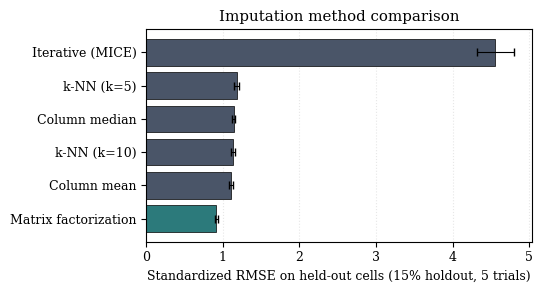

In [8]:
# Figure: imputation comparison
fig, ax = plt.subplots(figsize=(5.5, 3.0))
imp_sorted = imp_results.sort_values('Mean_RMSE')
colors = ['#2c7a7b' if m == 'Matrix factorization' else '#4a5568' for m in imp_sorted['Method']]
ax.barh(imp_sorted['Method'], imp_sorted['Mean_RMSE'], xerr=imp_sorted['Std'],
        color=colors, edgecolor='black', linewidth=0.5,
        error_kw={'linewidth': 0.8, 'capsize': 3})
ax.set_xlabel('Standardized RMSE on held-out cells (15% holdout, 5 trials)')
ax.set_title('Imputation method comparison')
ax.grid(axis='x', alpha=0.3, linestyle=':')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig_imputation.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_imputation.png', dpi=200, bbox_inches='tight')
plt.show()

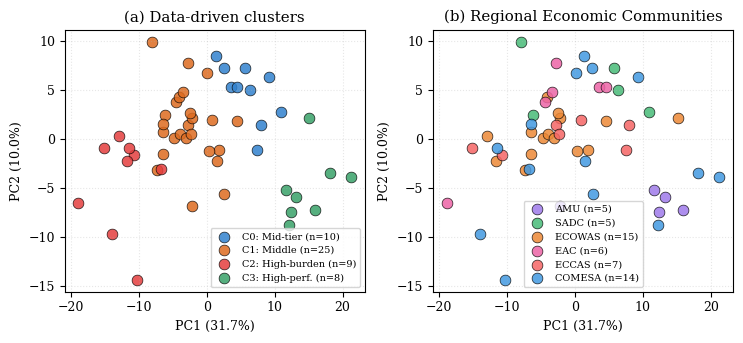

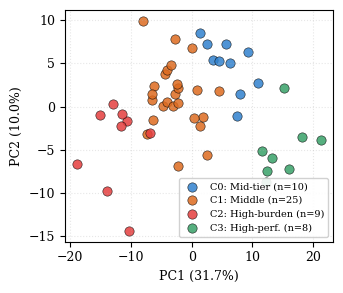

In [9]:
# Figure: PCA two-panel (clusters vs RECs)
explained = pca.explained_variance_ratio_
cluster_colors = {0: '#3182ce', 1: '#dd6b20', 2: '#e53e3e', 3: '#38a169'}
rec_colors = {'AMU': '#9f7aea', 'EAC': '#ed64a6', 'COMESA': '#4299e1',
              'SADC': '#48bb78', 'ECOWAS': '#ed8936', 'ECCAS': '#f56565'}

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.5))
for c in sorted(out['cluster_km'].unique()):
    sub = out[out['cluster_km'] == c]
    axes[0].scatter(sub['PC1'], sub['PC2'], c=cluster_colors[c],
                    label=f'C{c}: {names[c]} (n={len(sub)})', s=60,
                    edgecolor='black', linewidth=0.5, alpha=0.85)
axes[0].set(xlabel=f'PC1 ({explained[0]*100:.1f}%)', ylabel=f'PC2 ({explained[1]*100:.1f}%)',
            title='(a) Data-driven clusters')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3, linestyle=':')

for r in out['REC'].unique():
    sub = out[out['REC'] == r]
    axes[1].scatter(sub['PC1'], sub['PC2'], c=rec_colors[r],
                    label=f'{r} (n={len(sub)})', s=60,
                    edgecolor='black', linewidth=0.5, alpha=0.85)
axes[1].set(xlabel=f'PC1 ({explained[0]*100:.1f}%)', ylabel=f'PC2 ({explained[1]*100:.1f}%)',
            title='(b) Regional Economic Communities')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3, linestyle=':')
plt.tight_layout()
plt.savefig('fig_pca.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig_pca.png', dpi=200, bbox_inches='tight')
plt.show()

# Compact single-panel PCA (used in the 4-page paper)
fig, ax = plt.subplots(figsize=(3.5, 3.0))
for c in sorted(out['cluster_km'].unique()):
    sub = out[out['cluster_km'] == c]
    ax.scatter(sub['PC1'], sub['PC2'], c=cluster_colors[c],
               label=f'C{c}: {names[c]} (n={len(sub)})', s=45,
               edgecolor='black', linewidth=0.4, alpha=0.85)
ax.set(xlabel=f'PC1 ({explained[0]*100:.1f}%)', ylabel=f'PC2 ({explained[1]*100:.1f}%)')
ax.legend(fontsize=7, framealpha=0.9); ax.grid(alpha=0.3, linestyle=':')
plt.tight_layout()
plt.savefig('fig_pca_compact.pdf', dpi=300, bbox_inches='tight')
plt.show()

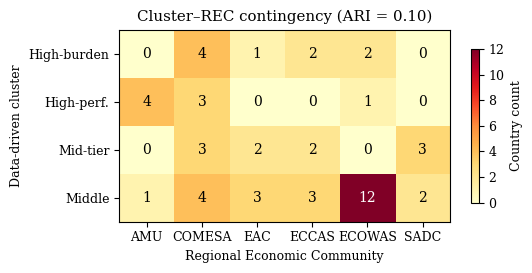

In [10]:
# Figure: contingency heatmap
fig, ax = plt.subplots(figsize=(5.5, 2.8))
im = ax.imshow(ct.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(len(ct.index)));   ax.set_yticklabels(ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        ax.text(j, i, str(v), ha='center', va='center', fontsize=10,
                color='white' if v > ct.values.max()*0.5 else 'black')
ax.set_xlabel('Regional Economic Community')
ax.set_ylabel('Data-driven cluster')
ax.set_title('Cluster–REC contingency (ARI = 0.10)')
plt.colorbar(im, ax=ax, label='Country count', shrink=0.8)
plt.tight_layout()
plt.savefig('fig_contingency.pdf', dpi=300, bbox_inches='tight')
plt.show()

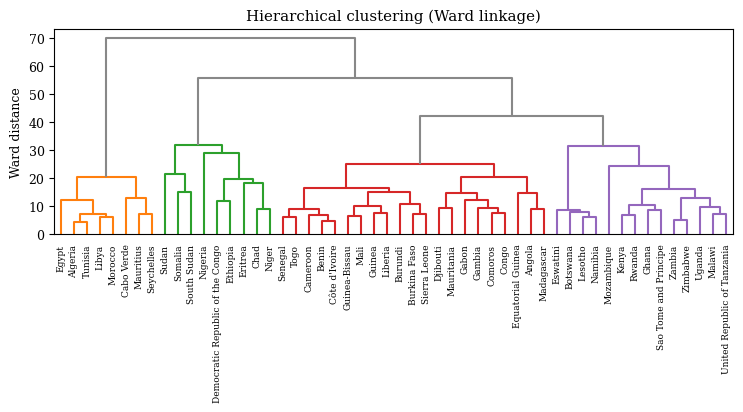

In [11]:
# Optional: Hierarchical dendrogram
from scipy.cluster.hierarchy import dendrogram
Z = linkage(X_pca, method='ward')
fig, ax = plt.subplots(figsize=(7.5, 4.2))
dendrogram(Z, labels=X_imp.index.tolist(), leaf_font_size=6.5,
           color_threshold=Z[-3, 2], above_threshold_color='#888')
ax.set_ylabel('Ward distance')
ax.set_title('Hierarchical clustering (Ward linkage)')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig('fig_dendrogram.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 5. Download outputs

In [ ]:
# In Colab, download all outputs
try:
    from google.colab import files
    for f in ['imputation_results.csv', 'cluster_assignments.csv', 'imputed_matrix.csv',
             'fig_imputation.pdf', 'fig_pca.pdf', 'fig_pca_compact.pdf',
             'fig_contingency.pdf', 'fig_dendrogram.pdf']:
        try:    files.download(f)
        except Exception as e: print(f'skip {f}: {e}')
except ImportError:
    print('Not running in Colab — outputs are in the working directory.')